# 02 — Preprocessing

Objectif : créer une colonne `sentiment` à partir de `Score` et préparer les features texte. Visualisation des impacts du preprocessing sur les données.

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

# Fix for Spark/Java compatibility
os.environ["JAVA_HOME"] = r"C:\Program Files\Java\jdk-17"

spark = (
    SparkSession.builder
    .appName("AmazonFoodReviews-Preprocessing")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

DATA_PATH = Path("../data/Reviews.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../Reviews.csv")

print("Using dataset:", DATA_PATH.resolve())

Using dataset: C:\Users\lenovo\Desktop\Data Engineering\mini-projest 2\data\Reviews.csv


In [2]:
df_raw = spark.read.csv(
    str(DATA_PATH), 
    header=True, 
    inferSchema=True,
    multiLine=True,
    escape='"'
)

df = (
    df_raw.select(
        F.col("Id").cast("long").alias("id"),
        F.col("Score").cast("int").alias("score"),
        F.col("Text").cast("string").alias("text"),
    )
    .filter(F.col("score").isNotNull())
    .na.drop(subset=["score", "text"])
    .withColumn("text", F.lower(F.col("text")))
    .withColumn("text", F.regexp_replace(F.col("text"), r"[^a-z0-9\s]", " "))
    .withColumn("text", F.regexp_replace(F.col("text"), r"\s+", " "))
)

# Labeling: 1–2 Negative, 3 Neutral, 4–5 Positive
df = df.withColumn(
    "sentiment",
    F.when(F.col("score").isin([1, 2]), F.lit("Negative"))
     .when(F.col("score") == 3, F.lit("Neutral"))
     .otherwise(F.lit("Positive"))
)

print("Sample of labeled data:")
df.select("score", "sentiment").show(5)

Sample of labeled data:
+-----+---------+
|score|sentiment|
+-----+---------+
|    5| Positive|
|    1| Negative|
|    4| Positive|
|    2| Negative|
|    5| Positive|
+-----+---------+
only showing top 5 rows


## 1. Sentiment Distribution

Visualisation de l'équilibre des classes.

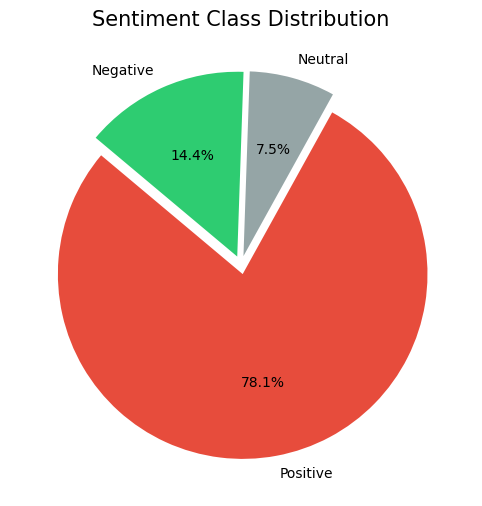

In [3]:
sentiment_counts = df.groupBy("sentiment").count().toPandas()

plt.figure(figsize=(10, 6))
colors = ["#e74c3c", "#95a5a6", "#2ecc71"] # Red, Grey, Green
plt.pie(sentiment_counts['count'], labels=sentiment_counts['sentiment'], 
        autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0.05, 0.05))
plt.title("Sentiment Class Distribution", fontsize=15)
plt.show()

## 2. Preprocessing Impact (Tokens)

On analyse la réduction du nombre de mots après nettoyage (stop words).

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10824\110572039.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stats_pd['token_count'], label='Before Stopwords Removal', shade=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_10824\110572039.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stats_pd['filtered_count'], label='After Stopwords Removal', shade=True)


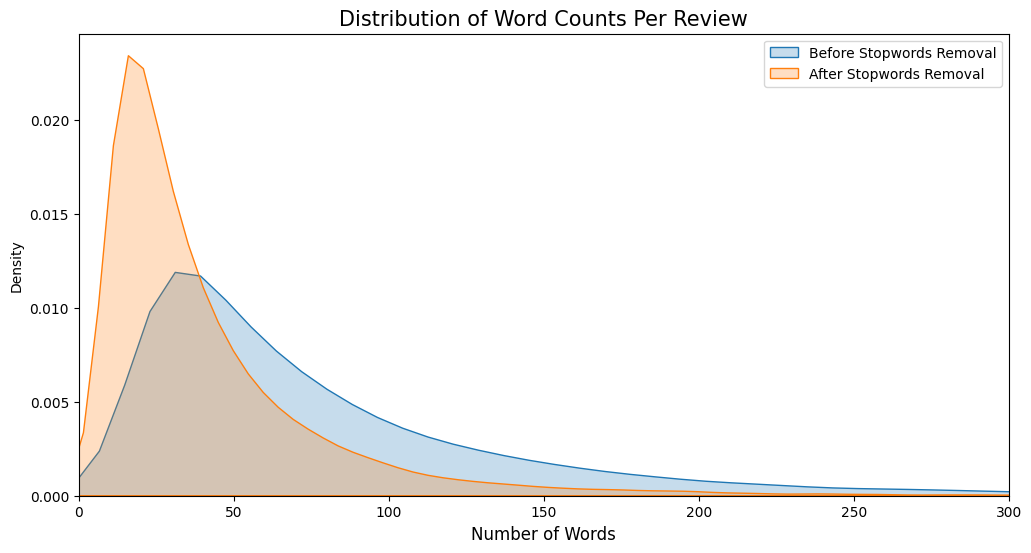

In [4]:
tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern=r"\W+")
stopwords = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")

pipe = Pipeline(stages=[tokenizer, stopwords])
model = pipe.fit(df)
df_tokens = model.transform(df)

df_stats = df_tokens.withColumn("token_count", F.size("tokens")) \
                    .withColumn("filtered_count", F.size("filtered_tokens"))

stats_pd = df_stats.select("token_count", "filtered_count").sample(0.05).toPandas()

plt.figure(figsize=(12, 6))
sns.kdeplot(stats_pd['token_count'], label='Before Stopwords Removal', shade=True)
sns.kdeplot(stats_pd['filtered_count'], label='After Stopwords Removal', shade=True)
plt.xlim(0, 300)
plt.title("Distribution of Word Counts Per Review", fontsize=15)
plt.xlabel("Number of Words", fontsize=12)
plt.legend()
plt.show()